# Notes as I go for results of various analyses

## Step 1: Quality control

Labeling was completed primarily by four UCSB undergraduate students: DSB, JL, KL, and MV, with each labeling roughly 600 images. First author Anna Boser labeled 51 images across 25 locations to serve as a quality control dataset, which all other labelers also labeled. Additionally, a native Zambian undergraduate student in the school of Agricultural Sciences at the University of Lusaka, Peter Siame, labeled one 25 location survey for each of the four other labelers to provide additional comparison data.

Here, we display the comparison results generated in labeler comparison. In particular, we compare metrics on (1) overall detection of any irrigation presence/absence at the image level and (2) overlap of the specific areas marked as irrigated.

In [13]:
import pandas as pd

In [10]:
# Read in the quality control outputs with certainty threshold 3

ab_area = pd.read_csv(
    '../outputs/quality_control/ab_comparisons_cert_3/area_overlap_metrics.csv')
ab_detection = pd.read_csv(
    '../outputs/quality_control/ab_comparisons_cert_3/image_detection_metrics.csv')
ps_area = pd.read_csv(

    '../outputs/quality_control/ps_comparisons_cert_3/area_overlap_metrics.csv')
ps_detection = pd.read_csv(
    '../outputs/quality_control/ps_comparisons_cert_3/image_detection_metrics.csv')

### Comparison to Anna Boser's labels

In [28]:
# Image-level detection metrics for comparison to Anna Boser
ab_detection

,Operator,Matched Images,Total Images Labeled,TP,FP,FN,TN,Precision,Recall,F1
0,DSB,47,588,12,0,4,31,1.0,0.750000,0.857143
1,JL,48,582,9,0,8,31,1.0,0.529412,0.692308
2,KL,48,681,12,0,4,32,1.0,0.750000,0.857143
3,MV,50,623,14,0,3,33,1.0,0.823529,0.903226
4,PS,48,204,9,0,7,32,1.0,0.562500,0.720000
5,Weighted Avg,241,2678,56,0,26,159,1.0,0.704883,0.821593


In [29]:
# Average F1 score across 4 primary labelers (weighted by number of images labeled by each labeler)
def weighted_metric(df, metric, labelers=['DSB', 'JL', 'KL', 'MV']):
    four_labelers = df[df['Operator'].isin(labelers)]
    weighted_metric = (four_labelers[metric] * four_labelers['Total Images Labeled']).sum() / four_labelers['Total Images Labeled'].sum()
    return weighted_metric

print(f'Image-level detection F1 Score:', weighted_metric(ab_detection, 'F1'))
print(f'Image-level detection Recall:', weighted_metric(ab_detection, 'Recall'))

Image-level detection F1 Score: 0.8299705093196108
Image-level detection Recall: 0.7166234723477103


Overall, we find a high degree of agreement with Anna Boser's labels at the iage level, with the average F1 score (weighted by the number of images labeled by each labeler) of 0.83 across the four primary labelers. Importantly, the precision for every labeler is 1, indicating that labelers do not generally erroneously find irrigation in images where there is none, though they may miss some, with a recall of 0.72. 

In [30]:
# Area overlap metrics for comparison to Anna Boser
ab_area

,Operator,Total Images Labeled,Precision,Recall,F1,IoU
0,DSB,588,0.586499,0.317768,0.412203,0.259607
1,JL,582,0.593105,0.268318,0.369483,0.226605
2,KL,681,0.750548,0.575316,0.651352,0.482967
3,MV,623,0.930122,0.354760,0.513620,0.345551
4,PS,204,0.782884,0.286984,0.420006,0.265827
5,Weighted Avg,2678,0.724550,0.378775,0.487921,0.329701


In [31]:
print(f'Area overlap F1 Score:', weighted_metric(ab_area, 'F1'))
print(f'Area overlap Precision:', weighted_metric(ab_area, 'Precision'))
print(f'Area overlap Recall:', weighted_metric(ab_area, 'Recall'))
print(f'Area overlap IoU:', weighted_metric(ab_area, 'IoU'))

Area overlap F1 Score: 0.4935208245334865
Area overlap Precision: 0.7197403916324517
Area overlap Recall: 0.3863438315715838
Area overlap IoU: 0.33496821653313363


Precision for area of overlap remains high, at 0.72. The disagreement likely stems from missed irrigation annotations by Anna Boser and an imperfect definition criteria: sometimes it is difficult to determine what is being "actively irrigated". For example, exacty how green should it be? 

Recall is low, at .38, suggesting that annotators do miss irrigated areas, either because they are generally small and hard to spot or again because it can be difficult to decide what is "irrigated enough". 

Overall, the F1 score for area of overlap is 0.49. 

This image demonstrates how it can be easy to miss irrigaed areas as well as feel unsure about how clearly and actively irrigated something must be to be counted as irrigated. 

![GEE_labeling_example.png](GEE_labeling_example.png)

![labels](../outputs/quality_control/ab_comparisons_cert_3/id_5062566_2019-06-14.png)



In general, these results suggest that while regions marked as irrigated in our dataset can be trusted to be irrigated, some areas that may be less obviously active or particularly small and difficult to spot may have been missed. For the purpose of training our dataset, this is likely to cause minimal issues because there is an overwhelming abundance of unirrigated area to train from. This is a bigger challenge for model testing, however, since a model with poor precision may actually simply be identifying irrigated regions the labeler missed. We therefore elect to exclusively use Karena Lai's labels for the test set, whose precision is high at 0.75 and recall is highest among all labelers at 0.57. We note that even with this precaution, model performance metrics may be somewhat unreliable, and model performance will also need to be visually assessed, especially when choosing detection thresholds. 

### Comparison to Peter Siame's Labels

When compared to Anna's labels, at the image level Peter has perfect precision and a recall of 0.56, and a precision of 0.78 and recall of 0.29 for area overlap. The high precision signifies that Peter does not erroneously mistake regions as irrigated that are not irrigated, which makes sense given he is a native Zambian studying agriculture, but the low recall suggests he does miss irrigated areas quite a bit, which is also unsurprising given how small and easy to miss they can be. 

In [20]:
ps_detection

,Operator,Matched Images,Total Images Labeled,TP,FP,FN,TN,Precision,Recall,F1
0,DSB,86,588,11,4,1,70,0.733333,0.916667,0.814815
1,JL,100,582,17,4,11,68,0.809524,0.607143,0.693878
2,KL,47,681,8,3,0,36,0.727273,1.000000,0.842105
3,MV,88,623,14,7,5,62,0.666667,0.736842,0.700000
4,Weighted Avg,321,2474,50,18,17,236,0.732801,0.821508,0.764964


In [23]:
ps_area

,Operator,Total Images Labeled,Precision,Recall,F1,IoU
0,DSB,588,0.340657,0.527323,0.413918,0.260969
1,JL,582,0.467366,0.407905,0.435616,0.278458
2,KL,681,0.376206,0.755558,0.502305,0.335386
3,MV,623,0.786966,0.808115,0.797400,0.663064
4,Weighted Avg,2474,0.492639,0.632764,0.539920,0.386822


When compared to Peter rather than Anna, labeler recall improves but precision diminises. F1 scores are similar to those calucalted when using Anna Boser's labels as ground truth. 

## Dataset Description

This section describes the dataset, including general polygon sizes, number of different locations labeled, number of images labeled, the distribution of the number of images labeled per location, and the distribution of area covered by irrigation in an image. 

In [47]:
# Read the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

irrigation_table = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_irrigation_table.csv')
polygons_table = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_polygons_table.csv')

# Filter to only include the four primary labelers
primary_labelers = ['DSB', 'KL', 'JL', 'MV']
irrigation_df = irrigation_table[irrigation_table['operator_initials'].isin(primary_labelers)].copy()
polygons_df = polygons_table[polygons_table['operator_initials'].isin(primary_labelers)].copy()

# Exclude survey 101-125 which was labeled by all four labelers for quality control
irrigation_df = irrigation_df[~irrigation_df['source_file'].str.contains('101-125', na=False)]
polygons_df = polygons_df[~polygons_df['source_file'].str.contains('101-125', na=False)]

# Add irrigation category labels
def get_irrigation_category(val):
    if val == 1:
        return 'No irrigation'
    elif val == 2:
        return 'Low certainty'
    elif val == 3:
        return 'Medium certainty'
    elif val == 4:
        return 'High certainty'
    elif val == 5:
        return 'Very high certainty'
    else:
        return 'Unknown'

irrigation_df['irrigation_category'] = irrigation_df['irrigation'].apply(get_irrigation_category)

# Create unique image identifier
irrigation_df['image_id'] = irrigation_df['site_id'] + '_' + irrigation_df['year'].astype(str) + '_' + irrigation_df['month'].astype(str) + '_' + irrigation_df['day'].astype(str)
polygons_df['image_id'] = polygons_df['site_id'] + '_' + polygons_df['year'].astype(str) + '_' + polygons_df['month'].astype(str) + '_' + polygons_df['day'].astype(str)

print(f"Loaded {len(irrigation_df)} images and {len(polygons_df)} polygons from primary labelers")
print(f"(Excluding survey 101-125 used for quality control)")

Loaded 2274 images and 3159 polygons from primary labelers
(Excluding survey 101-125 used for quality control)


### Summary Statistics: Locations, Images, and Polygons by Labeler

In [55]:
# Summary statistics by labeler
summary_stats = []

for labeler in primary_labelers:
    labeler_images = irrigation_df[irrigation_df['operator_initials'] == labeler]
    labeler_polygons = polygons_df[polygons_df['operator_initials'] == labeler]
    
    n_locations = labeler_images['site_id'].nunique()
    n_images = len(labeler_images)
    n_polygons = len(labeler_polygons)
    n_irrigated_images = len(labeler_images[labeler_images['irrigation'] >= 3]) # certainty of 3 and obove is included for our dataset
    pct_irrigated = n_irrigated_images / n_images * 100 if n_images > 0 else 0

    
    summary_stats.append({
        'Labeler': labeler,
        'Locations': n_locations,
        'Images': n_images,
        'Irrigated Images': n_irrigated_images,
        'Pct Irrigated Images': pct_irrigated,
        'Polygons': n_polygons,
        'Total area (sq meters)': labeler_polygons['polygon_area_m2'].sum()
    })

# Add total row
total_stats = {
    'Labeler': 'Total',
    'Locations': irrigation_df['site_id'].nunique(),
    'Images': len(irrigation_df),
    'Irrigated Images': len(irrigation_df[irrigation_df['irrigation'] >= 3]),
    'Pct Irrigated Images': len(irrigation_df[irrigation_df['irrigation'] >= 3]) / len(irrigation_df) * 100,
    'Polygons': len(polygons_df),
    'Total area (sq meters)': polygons_df['polygon_area_m2'].sum()
}
summary_stats.append(total_stats)

summary_df = pd.DataFrame(summary_stats)
summary_df

,Labeler,Locations,Images,Irrigated Images,Pct Irrigated Images,Polygons,Total area (sq meters)
0,DSB,222,539,143,26.530612,580,4.065766e+06
1,KL,244,632,180,28.481013,899,7.921616e+06
2,JL,212,531,154,29.001883,1267,2.405718e+06
3,MV,234,572,140,24.475524,413,3.770911e+06
4,Total,911,2274,617,27.132806,3159,1.816401e+07


### Distribution of Images per Location

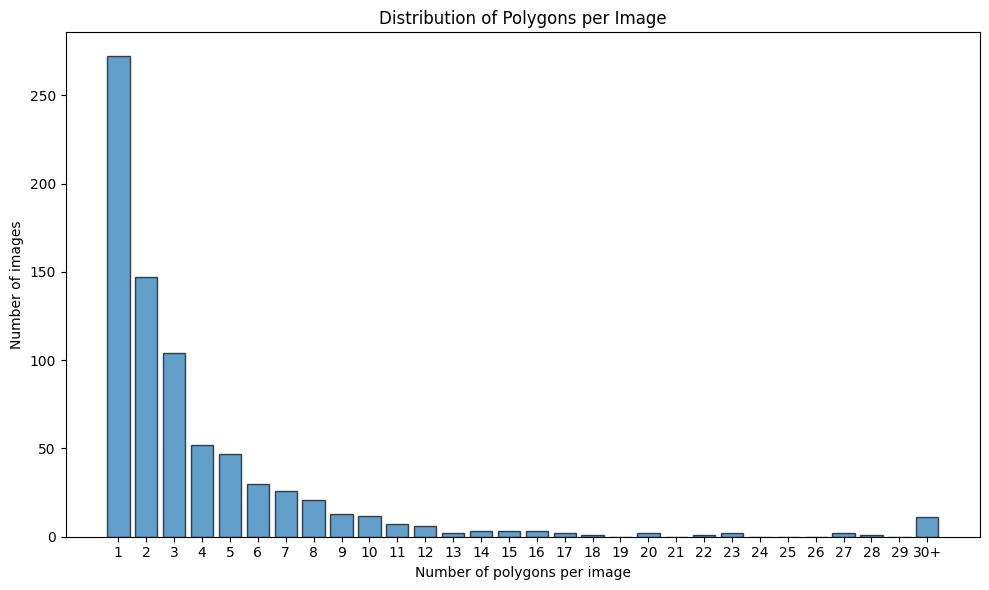

Images with polygons: 770
Mean polygons per image: 4.10
Median polygons per image: 2


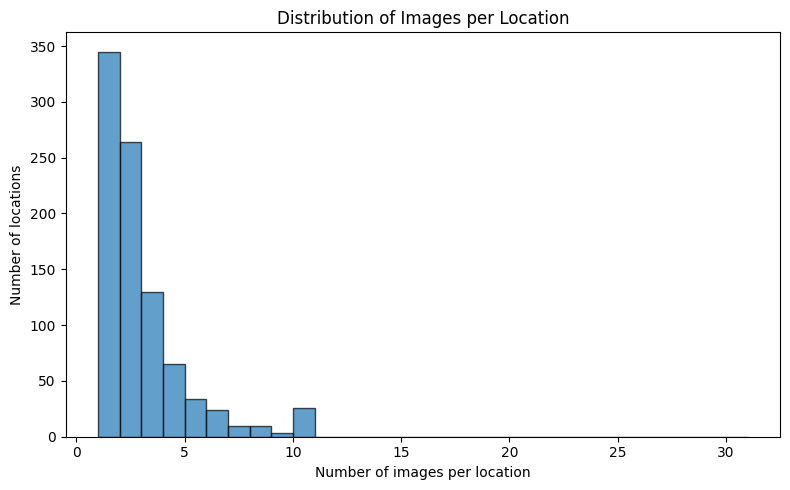

In [52]:
# Distribution of polygons per image (simple histogram)
polygons_per_image_count = polygons_df.groupby('image_id').size()

max_poly = min(int(polygons_per_image_count.max()), 30)
bins = range(1, max_poly + 2)

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram counts
hist_counts = []
for i in range(len(bins) - 1):
    bin_start, bin_end = bins[i], bins[i + 1]
    if i == len(bins) - 2:  # Last bin includes everything >= bin_start
        count = (polygons_per_image_count >= bin_start).sum()
    else:
        count = ((polygons_per_image_count >= bin_start) & (polygons_per_image_count < bin_end)).sum()
    hist_counts.append(count)

ax.bar(np.arange(len(bins) - 1) + 0.5, hist_counts, width=0.8, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of polygons per image')
ax.set_ylabel('Number of images')
ax.set_title('Distribution of Polygons per Image')
ax.set_xticks(np.arange(len(bins) - 1) + 0.5)
xlabels = [str(b) for b in bins[:-1]]
xlabels[-1] = f'{bins[-2]}+'
ax.set_xticklabels(xlabels)
plt.tight_layout()
plt.show()

print(f"Images with polygons: {len(polygons_per_image_count)}")
print(f"Mean polygons per image: {polygons_per_image_count.mean():.2f}")
print(f"Median polygons per image: {polygons_per_image_count.median():.0f}")

# Also show the histogram of locations (not images) per bin
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(total_per_location, bins=bins, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of images per location')
ax.set_ylabel('Number of locations')
ax.set_title('Distribution of Images per Location')
plt.tight_layout()
plt.show()

Most locations have one image, but most images come from a location with two images. I find the first plot confusing, though I like the second one. I think the first one should be repaced by the number of images on the y axis BUT the number of polygons per image on the x axis instead. 

### Distribution of Polygons per Image

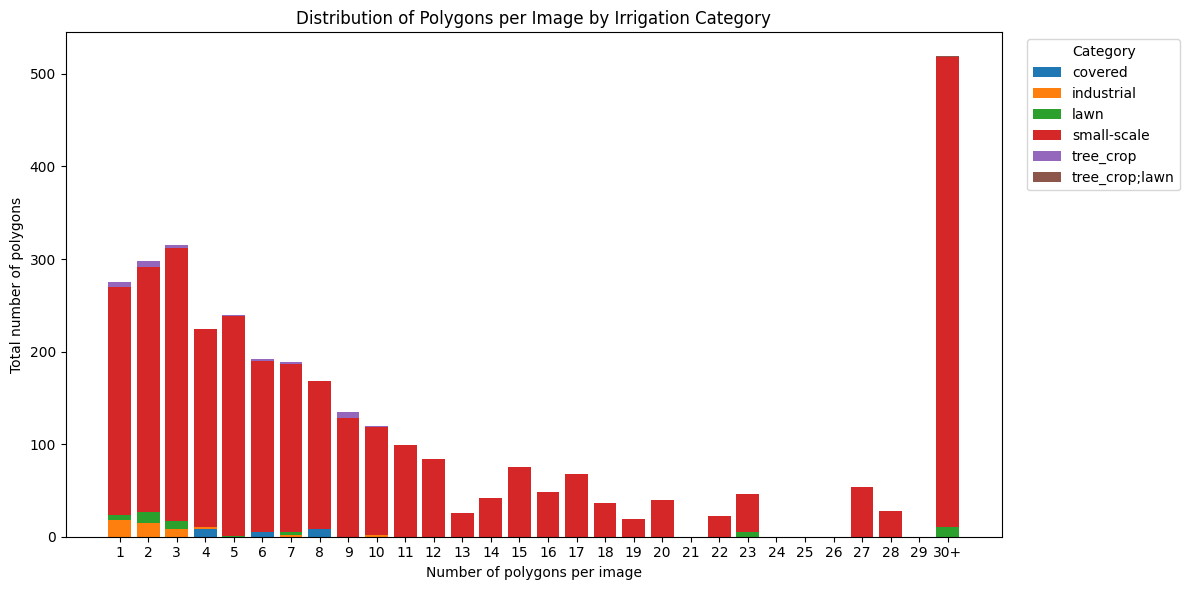

Images with polygons: 795
Mean polygons per image: 4.23
Median polygons per image: 2
Max polygons per image: 62


In [35]:
# Distribution of polygons per image, stacked by category
# First, count polygons per image by category
polygons_per_image = polygons_df.groupby(['image_id', 'category']).size().unstack(fill_value=0)

# Get total polygons per image
total_polygons_per_image = polygons_per_image.sum(axis=1)

# Create bins
max_polygons = min(int(total_polygons_per_image.max()), 30)  # Cap at 30 for readability
bins = range(1, max_polygons + 2)

# Category colors for polygons
poly_categories = polygons_df['category'].unique()
poly_colors = plt.cm.Set2(np.linspace(0, 1, len(poly_categories)))
poly_color_map = dict(zip(poly_categories, poly_colors))

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(bins) - 1)
for cat in sorted(polygons_per_image.columns):
    cat_counts = []
    for i in range(len(bins) - 1):
        bin_start, bin_end = bins[i], bins[i + 1]
        if i == len(bins) - 2:  # Last bin includes everything >= bin_start
            mask = total_polygons_per_image >= bin_start
        else:
            mask = (total_polygons_per_image >= bin_start) & (total_polygons_per_image < bin_end)
        cat_counts.append(polygons_per_image.loc[mask, cat].sum())
    ax.bar(np.arange(len(bins) - 1) + 0.5, cat_counts, bottom=bottom, 
           label=cat, width=0.8)
    bottom += np.array(cat_counts)

ax.set_xlabel('Number of polygons per image')
ax.set_ylabel('Total number of polygons')
ax.set_title('Distribution of Polygons per Image by Irrigation Category')
ax.set_xticks(np.arange(len(bins) - 1) + 0.5)
xlabels = [str(b) for b in bins[:-1]]
xlabels[-1] = f'{bins[-2]}+'
ax.set_xticklabels(xlabels)
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Images with polygons: {len(total_polygons_per_image)}")
print(f"Mean polygons per image: {total_polygons_per_image.mean():.2f}")
print(f"Median polygons per image: {total_polygons_per_image.median():.0f}")
print(f"Max polygons per image: {total_polygons_per_image.max():.0f}")

### Distribution of Polygon Sizes by Category

In [ ]:
# Distribution of polygon sizes by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw histogram
ax = axes[0]
categories = sorted(polygons_df['category'].unique())
for cat in categories:
    cat_data = polygons_df[polygons_df['category'] == cat]['polygon_area_m2']
    ax.hist(cat_data, bins=50, alpha=0.6, label=cat)
ax.set_xlabel('Polygon area (m²)')
ax.set_ylabel('Number of polygons')
ax.set_title('Distribution of Polygon Sizes by Category')
ax.legend(title='Category')
ax.set_xlim(0, polygons_df['polygon_area_m2'].quantile(0.99))  # Clip at 99th percentile

# Right: log scale
ax = axes[1]
for cat in categories:
    cat_data = polygons_df[polygons_df['category'] == cat]['polygon_area_m2']
    # Add small epsilon to avoid log(0)
    ax.hist(cat_data, bins=np.logspace(np.log10(cat_data.min() + 0.01), 
                                        np.log10(cat_data.max() + 0.01), 50), 
            alpha=0.6, label=cat)
ax.set_xscale('log')
ax.set_xlabel('Polygon area (m²) - log scale')
ax.set_ylabel('Number of polygons')
ax.set_title('Distribution of Polygon Sizes by Category (Log Scale)')
ax.legend(title='Category')

plt.tight_layout()
plt.show()

# Summary statistics

print("Polygon size statistics by category (m²):")print(polygons_df.groupby('category')['polygon_area_m2'].describe().round(2))

SyntaxError: invalid syntax (119593185.py, line 37)

### Distribution of Irrigation Coverage per Image

In [ ]:
# Distribution of irrigation coverage per image
# Note: "High certainty" coverage includes polygons with certainty >= 3 
# (defined in src/processing/merge_survey_and_polygons.py)

# Only include images with irrigation (percent_coverage > 0)
irrigated_images = irrigation_df[irrigation_df['percent_coverage'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of percent coverage
ax = axes[0]
ax.hist(irrigated_images['percent_coverage'] * 100, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Irrigation coverage (%)')
ax.set_ylabel('Number of images')
ax.set_title('Distribution of Irrigation Coverage per Image')
ax.axvline(irrigated_images['percent_coverage'].mean() * 100, color='red', 
           linestyle='--', label=f'Mean: {irrigated_images["percent_coverage"].mean()*100:.2f}%')
ax.axvline(irrigated_images['percent_coverage'].median() * 100, color='orange', 
           linestyle='--', label=f'Median: {irrigated_images["percent_coverage"].median()*100:.2f}%')
ax.legend()

# Right: histogram of high-certainty percent coverage (certainty >= 3)
ax = axes[1]
irrigated_hc = irrigation_df[irrigation_df['percent_coverage_hc'] > 0].copy()
ax.hist(irrigated_hc['percent_coverage_hc'] * 100, bins=50, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('High-certainty irrigation coverage (%)')
ax.set_ylabel('Number of images')
ax.set_title('Distribution of High-Certainty (certainty >= 3) Coverage per Image')
ax.axvline(irrigated_hc['percent_coverage_hc'].mean() * 100, color='red', 
           linestyle='--', label=f'Mean: {irrigated_hc["percent_coverage_hc"].mean()*100:.2f}%')
ax.axvline(irrigated_hc['percent_coverage_hc'].median() * 100, color='orange', 
           linestyle='--', label=f'Median: {irrigated_hc["percent_coverage_hc"].median()*100:.2f}%')
ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Images with any irrigation: {len(irrigated_images)}")
print(f"Mean coverage: {irrigated_images['percent_coverage'].mean()*100:.2f}%")
print(f"Median coverage: {irrigated_images['percent_coverage'].median()*100:.2f}%")
print(f"Max coverage: {irrigated_images['percent_coverage'].max()*100:.2f}%")
print(f"\nImages with high-certainty irrigation (certainty >= 3): {len(irrigated_hc)}")
print(f"Mean high-certainty coverage: {irrigated_hc['percent_coverage_hc'].mean()*100:.2f}%")
print(f"Median high-certainty coverage: {irrigated_hc['percent_coverage_hc'].median()*100:.2f}%")

### Irrigation Detection by Month

In [ ]:
# Irrigation detection by month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Image-level detection rate by month
ax = axes[0, 0]
monthly_stats = irrigation_df.groupby('month').agg({
    'unique_id': 'count',
    'irrigation': lambda x: (x > 1).sum()
}).rename(columns={'unique_id': 'total_images', 'irrigation': 'irrigated_images'})
monthly_stats['detection_rate'] = monthly_stats['irrigated_images'] / monthly_stats['total_images']

ax.bar(monthly_stats.index, monthly_stats['detection_rate'] * 100, color='steelblue', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Irrigation detection rate (%)')
ax.set_title('Image-Level Irrigation Detection Rate by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
for i, (idx, row) in enumerate(monthly_stats.iterrows()):
    ax.annotate(f'n={int(row["total_images"])}', (idx, row['detection_rate']*100 + 1), 
                ha='center', fontsize=8)

# 2. Number of irrigated images by month
ax = axes[0, 1]
ax.bar(monthly_stats.index, monthly_stats['irrigated_images'], color='green', edgecolor='black', label='Irrigated')
ax.bar(monthly_stats.index, monthly_stats['total_images'] - monthly_stats['irrigated_images'], 
       bottom=monthly_stats['irrigated_images'], color='gray', edgecolor='black', alpha=0.5, label='Not irrigated')
ax.set_xlabel('Month')
ax.set_ylabel('Number of images')
ax.set_title('Number of Images by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.legend()

# 3. Mean irrigation coverage by month (for images with irrigation)
ax = axes[1, 0]
monthly_coverage = irrigation_df[irrigation_df['percent_coverage'] > 0].groupby('month')['percent_coverage'].mean() * 100
ax.bar(monthly_coverage.index, monthly_coverage.values, color='orange', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Mean irrigation coverage (%)')
ax.set_title('Mean Irrigation Coverage by Month (Irrigated Images Only)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)

# 4. Total irrigated area by month
ax = axes[1, 1]
polygons_df_monthly = polygons_df.groupby('month')['polygon_area_m2'].sum() / 10000  # Convert to hectares
ax.bar(polygons_df_monthly.index, polygons_df_monthly.values, color='purple', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Total irrigated area (hectares)')
ax.set_title('Total Labeled Irrigation Area by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.show()

# Summary table
print("Monthly irrigation summary:")
monthly_summary = monthly_stats.copy()
monthly_summary['mean_coverage_%'] = irrigation_df[irrigation_df['percent_coverage'] > 0].groupby('month')['percent_coverage'].mean() * 100
monthly_summary['total_area_ha'] = polygons_df.groupby('month')['polygon_area_m2'].sum() / 10000
monthly_summary.index = month_names
print(monthly_summary.round(2))

### KL-Only Dataset Statistics

Since Karena Lai's (KL) labels were found to have the highest precision and recall compared to ground truth, we use her labels exclusively for the test set. Below we present the same statistics for the KL-labeled portion of the dataset.

In [ ]:
# Filter to KL only
kl_irrigation = irrigation_df[irrigation_df['operator_initials'] == 'KL'].copy()
kl_polygons = polygons_df[polygons_df['operator_initials'] == 'KL'].copy()

# Summary statistics
print("=" * 50)
print("KL Dataset Summary")
print("=" * 50)
print(f"Locations: {kl_irrigation['site_id'].nunique()}")
print(f"Images: {len(kl_irrigation)}")
print(f"Irrigated images: {len(kl_irrigation[kl_irrigation['irrigation'] > 1])}")
print(f"Polygons: {len(kl_polygons)}")

In [ ]:
# KL: Distribution of images per location
kl_images_per_location = kl_irrigation.groupby(['site_id', 'irrigation_category']).size().unstack(fill_value=0)
kl_images_per_location = kl_images_per_location.reindex(columns=[c for c in category_order if c in kl_images_per_location.columns])
kl_total_per_location = kl_images_per_location.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(kl_total_per_location, bins=range(1, int(kl_total_per_location.max()) + 2), edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of images per location')
ax.set_ylabel('Number of locations')
ax.set_title('KL: Distribution of Images per Location')
plt.tight_layout()
plt.show()

In [ ]:
# KL: Distribution of polygons per image
kl_polygons_per_image = kl_polygons.groupby(['image_id', 'category']).size().unstack(fill_value=0)
kl_total_polygons_per_image = kl_polygons_per_image.sum(axis=1)

max_poly = min(int(kl_total_polygons_per_image.max()), 30)
bins = range(1, max_poly + 2)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(bins) - 1)
for cat in sorted(kl_polygons_per_image.columns):
    cat_counts = []
    for i in range(len(bins) - 1):
        bin_start, bin_end = bins[i], bins[i + 1]
        if i == len(bins) - 2:
            mask = kl_total_polygons_per_image >= bin_start
        else:
            mask = (kl_total_polygons_per_image >= bin_start) & (kl_total_polygons_per_image < bin_end)
        cat_counts.append(kl_polygons_per_image.loc[mask, cat].sum())
    ax.bar(np.arange(len(bins) - 1) + 0.5, cat_counts, bottom=bottom, label=cat, width=0.8)
    bottom += np.array(cat_counts)

ax.set_xlabel('Number of polygons per image')
ax.set_ylabel('Total number of polygons')
ax.set_title('KL: Distribution of Polygons per Image by Category')
ax.set_xticks(np.arange(len(bins) - 1) + 0.5)
xlabels = [str(b) for b in bins[:-1]]
xlabels[-1] = f'{bins[-2]}+'
ax.set_xticklabels(xlabels)
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"KL images with polygons: {len(kl_total_polygons_per_image)}")
print(f"Mean polygons per image: {kl_total_polygons_per_image.mean():.2f}")
print(f"Median polygons per image: {kl_total_polygons_per_image.median():.0f}")

In [ ]:
# KL: Distribution of polygon sizes by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw histogram
ax = axes[0]
kl_categories = sorted(kl_polygons['category'].unique())
for cat in kl_categories:
    cat_data = kl_polygons[kl_polygons['category'] == cat]['polygon_area_m2']
    ax.hist(cat_data, bins=50, alpha=0.6, label=cat)
ax.set_xlabel('Polygon area (m²)')
ax.set_ylabel('Number of polygons')
ax.set_title('KL: Distribution of Polygon Sizes by Category')
ax.legend(title='Category')
ax.set_xlim(0, kl_polygons['polygon_area_m2'].quantile(0.99))

# Right: log scale
ax = axes[1]
for cat in kl_categories:
    cat_data = kl_polygons[kl_polygons['category'] == cat]['polygon_area_m2']
    # Add small epsilon to avoid log(0)
    ax.hist(cat_data, bins=np.logspace(np.log10(cat_data.min() + 0.01), 
                                        np.log10(cat_data.max() + 0.01), 50), 
            alpha=0.6, label=cat)
ax.set_xscale('log')
ax.set_xlabel('Polygon area (m²) - log scale')
ax.set_ylabel('Number of polygons')
ax.set_title('KL: Distribution of Polygon Sizes (Log Scale)')
ax.legend(title='Category')

plt.tight_layout()
plt.show()


print("KL polygon size statistics by category (m²):")print(kl_polygons.groupby('category')['polygon_area_m2'].describe().round(2))

In [ ]:
# KL: Distribution of irrigation coverage
# Note: "High certainty" coverage includes polygons with certainty >= 3

kl_irrigated_images = kl_irrigation[kl_irrigation['percent_coverage'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of percent coverage
ax = axes[0]
ax.hist(kl_irrigated_images['percent_coverage'] * 100, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Irrigation coverage (%)')
ax.set_ylabel('Number of images')
ax.set_title('KL: Distribution of Irrigation Coverage per Image')
ax.axvline(kl_irrigated_images['percent_coverage'].mean() * 100, color='red', 
           linestyle='--', label=f'Mean: {kl_irrigated_images["percent_coverage"].mean()*100:.2f}%')
ax.axvline(kl_irrigated_images['percent_coverage'].median() * 100, color='orange', 
           linestyle='--', label=f'Median: {kl_irrigated_images["percent_coverage"].median()*100:.2f}%')
ax.legend()

# Right: high-certainty coverage (certainty >= 3)
ax = axes[1]
kl_irrigated_hc = kl_irrigation[kl_irrigation['percent_coverage_hc'] > 0].copy()
ax.hist(kl_irrigated_hc['percent_coverage_hc'] * 100, bins=50, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('High-certainty irrigation coverage (%)')
ax.set_ylabel('Number of images')
ax.set_title('KL: High-Certainty (certainty >= 3) Coverage per Image')
ax.axvline(kl_irrigated_hc['percent_coverage_hc'].mean() * 100, color='red', 
           linestyle='--', label=f'Mean: {kl_irrigated_hc["percent_coverage_hc"].mean()*100:.2f}%')
ax.axvline(kl_irrigated_hc['percent_coverage_hc'].median() * 100, color='orange', 
           linestyle='--', label=f'Median: {kl_irrigated_hc["percent_coverage_hc"].median()*100:.2f}%')
ax.legend()

plt.tight_layout()
plt.show()

print(f"KL images with any irrigation: {len(kl_irrigated_images)}")
print(f"Mean coverage: {kl_irrigated_images['percent_coverage'].mean()*100:.2f}%")
print(f"Median coverage: {kl_irrigated_images['percent_coverage'].median()*100:.2f}%")

In [ ]:
# KL: Irrigation detection by month
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Image-level detection rate by month
ax = axes[0, 0]
kl_monthly_stats = kl_irrigation.groupby('month').agg({
    'unique_id': 'count',
    'irrigation': lambda x: (x > 1).sum()
}).rename(columns={'unique_id': 'total_images', 'irrigation': 'irrigated_images'})
kl_monthly_stats['detection_rate'] = kl_monthly_stats['irrigated_images'] / kl_monthly_stats['total_images']

ax.bar(kl_monthly_stats.index, kl_monthly_stats['detection_rate'] * 100, color='steelblue', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Irrigation detection rate (%)')
ax.set_title('KL: Image-Level Irrigation Detection Rate by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
for i, (idx, row) in enumerate(kl_monthly_stats.iterrows()):
    ax.annotate(f'n={int(row["total_images"])}', (idx, row['detection_rate']*100 + 1), 
                ha='center', fontsize=8)

# 2. Number of images by month
ax = axes[0, 1]
ax.bar(kl_monthly_stats.index, kl_monthly_stats['irrigated_images'], color='green', edgecolor='black', label='Irrigated')
ax.bar(kl_monthly_stats.index, kl_monthly_stats['total_images'] - kl_monthly_stats['irrigated_images'], 
       bottom=kl_monthly_stats['irrigated_images'], color='gray', edgecolor='black', alpha=0.5, label='Not irrigated')
ax.set_xlabel('Month')
ax.set_ylabel('Number of images')
ax.set_title('KL: Number of Images by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.legend()

# 3. Mean irrigation coverage by month
ax = axes[1, 0]
kl_monthly_coverage = kl_irrigation[kl_irrigation['percent_coverage'] > 0].groupby('month')['percent_coverage'].mean() * 100
ax.bar(kl_monthly_coverage.index, kl_monthly_coverage.values, color='orange', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Mean irrigation coverage (%)')
ax.set_title('KL: Mean Irrigation Coverage by Month (Irrigated Images Only)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)

# 4. Total irrigated area by month
ax = axes[1, 1]
kl_polygons_monthly = kl_polygons.groupby('month')['polygon_area_m2'].sum() / 10000  # Convert to hectares
ax.bar(kl_polygons_monthly.index, kl_polygons_monthly.values, color='purple', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Total irrigated area (hectares)')
ax.set_title('KL: Total Labeled Irrigation Area by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.show()

# Summary table
print("KL Monthly irrigation summary:")
kl_monthly_summary = kl_monthly_stats.copy()
kl_monthly_coverage_series = kl_irrigation[kl_irrigation['percent_coverage'] > 0].groupby('month')['percent_coverage'].mean() * 100
kl_monthly_summary['mean_coverage_%'] = kl_monthly_coverage_series
kl_monthly_summary['total_area_ha'] = kl_polygons.groupby('month')['polygon_area_m2'].sum() / 10000
kl_monthly_summary.index = [month_names[i-1] for i in kl_monthly_summary.index]
print(kl_monthly_summary.round(2))

## Splits

This section describes how we choose to split data. Things to consider: 
- Split by location, not image
- How big should I make the test set??
- Karena's images will make up the test set. Though maybe this will make it extra extra hard for the model since it won't have been trained on her labels at all. Though I guess that's even more unbiased. 
- Should we have a seperate validation set or do cross-val? Do we have enough data not to do crossval? 